In [2]:
from __future__ import print_function
from astropy.io import fits
import os
import numpy as np
import glob
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from pathlib import Path

In [3]:


ROOT_PATH = Path("../Spectra-shooter/")



In [4]:
hdulist = fits.open(ROOT_PATH / "ADP.2014-05-15T15_28_46.063.fits")
hdulist.info()

Filename: ../Spectra-shooter/ADP.2014-05-15T15_28_46.063.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  FLUX          1 PrimaryHDU     659   (24750, 76)   float32   
  1  ERRS          1 ImageHDU        32   (24750, 76)   float32   
  2  QUAL          1 ImageHDU        31   (24750, 76)   int32   


In [5]:
hdulist[1].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                24750 / length of data axis 1                          
NAXIS2  =                   76 / length of data axis 2                          
PCOUNT  =                    0 / required keyword; must = 0                     
GCOUNT  =                    1 / required keyword; must = 1                     
EXTNAME = 'ERRS    '                                                            
BUNIT   = 'ADU     '                                                            
HDUCLASS= 'ESO     '           / hdu classification                             
HDUDOC  = 'DICD    '           / hdu reference document                         
HDUVERS = 'DICD V6.0'          / hdu reference document version                 
HDUCLAS1= 'IMAGE   '        

In [6]:
# Obtener datos
flux_data = hdulist[0].data  # Forma (24750, 76)

In [7]:
# Crear array de longitudes de onda
crval1 = hdulist[1].header['CRVAL1']  # 994.02
cdelt1 = hdulist[1].header['CDELT1']  # 0.06
n_pixels = flux_data.shape[0]  # 24750
wavelength = crval1 + np.arange(n_pixels) * cdelt1


In [13]:
# Elegir un espectro específico (columna)
spectrum_num = 1  # Cambia este número entre 0-75 para diferentes espectros
spectrum = flux_data[:, spectrum_num]

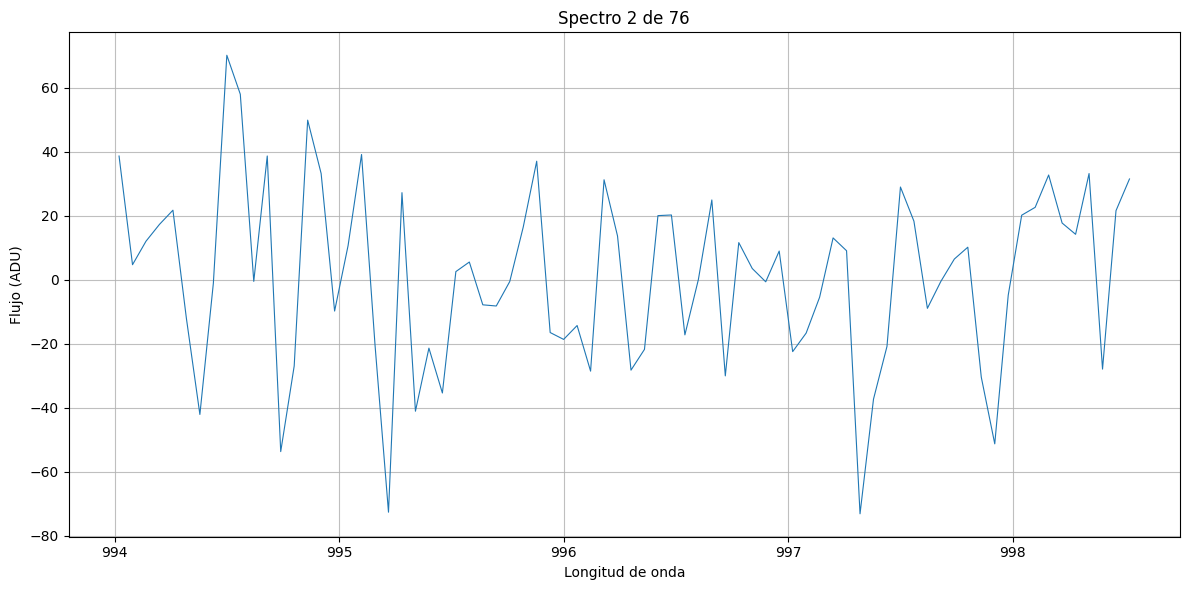

In [14]:
# Plotear
plt.figure(figsize=(12, 6))
plt.plot(wavelength, spectrum, linewidth=0.8)
plt.xlabel('Longitud de onda')
plt.ylabel('Flujo (ADU)')
plt.title(f'Spectro {spectrum_num + 1} de 76')
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

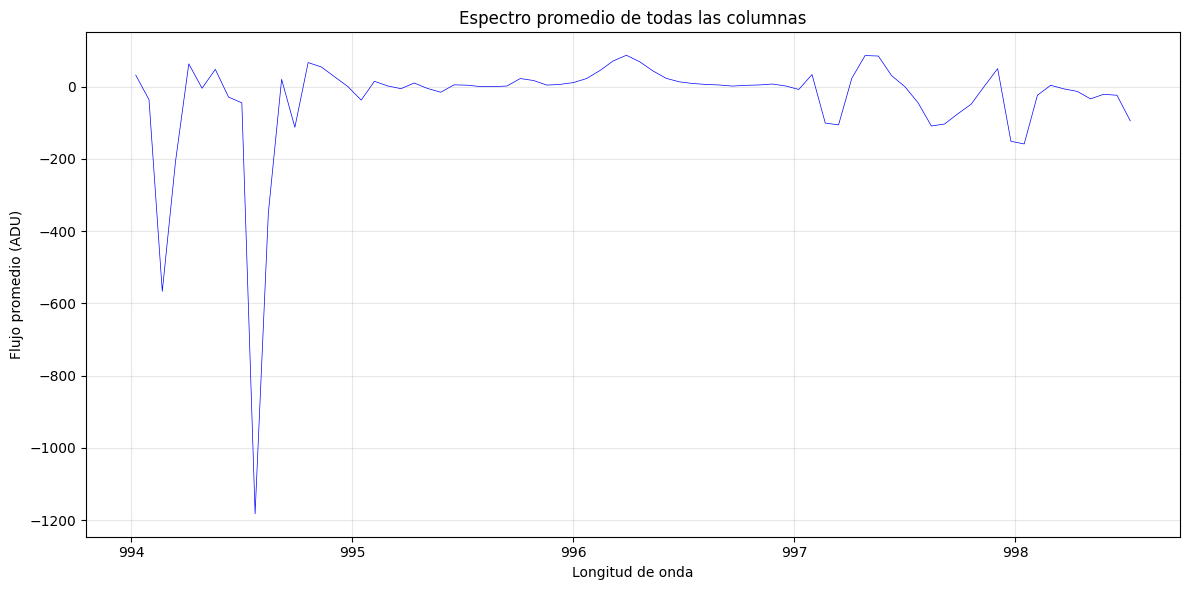

In [12]:
# Promediar todos los espectros (eje 1 = columnas)
mean_spectrum = np.mean(flux_data, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(wavelength, mean_spectrum, linewidth=0.5, color='blue')
plt.xlabel('Longitud de onda')
plt.ylabel('Flujo promedio (ADU)')
plt.title('Espectro promedio de todas las columnas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()